In [42]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [43]:
df=pd.read_csv("spam.csv.zip",encoding="latin-1")

In [44]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [45]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])


In [46]:
df.columns=["label","message"]

In [47]:
df.columns


Index(['label', 'message'], dtype='object')

In [48]:
df.shape

(5572, 2)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [50]:
df.isnull().sum()

,0
label,0
message,0


In [51]:
df.duplicated().sum()


np.int64(403)

In [52]:
df=df.drop_duplicates()

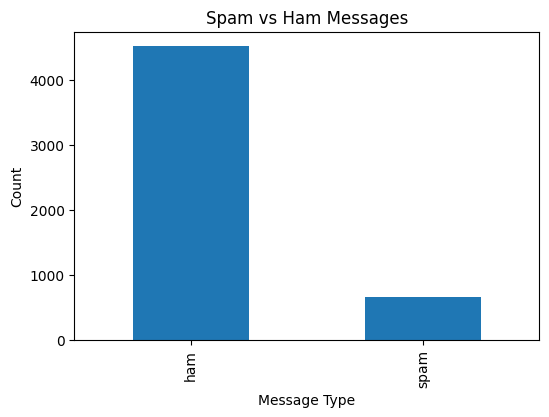

In [53]:
plt.figure(figsize=(6,4))
df["label"].value_counts().plot(kind="bar")
plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [54]:
cv=CountVectorizer()

In [55]:
X=cv.fit_transform(df["message"])

In [56]:
y=df["label"]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [58]:
model=MultinomialNB()

In [59]:
model.fit(X_train,y_train)

MultinomialNB()

In [60]:
y_pred=model.predict(X_test)

In [61]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",round(accuracy*100,2),"%")

Accuracy: 98.26 %


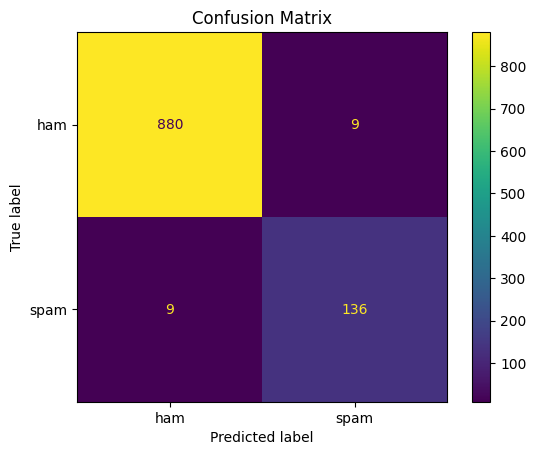

In [62]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

In [65]:
user_message=input("Enter a message:")
user_message_count=cv.transform([user_message])
prediction=model.predict(user_message_count)
probability=model.predict_proba(user_message_count)
confidence=max(probability[0])*100
print("Prediction:",prediction[0])
print("Probability:",round(confidence,2),"%")
if prediction[0]=="spam":
    print("The message is spam")
else:
    print("The message is not spam")

Enter a message:Congratulations you won the free lottery
Prediction: spam
Probability: 98.4 %
The message is spam
